# Analytical Noise Schedule: Proof-of-Concept Simulation

Runs the analytically derived continuous noise schedule $\sigma(t)$ (recovered from the human forgetting curve) through the full simulation pipeline and compares the resulting ' curve to human data.

**Key idea**: Invert $d'(t) = a(t+t_0)^{-\alpha}$ + d_\infty$ to get $\sigma^2(t) = -2\Delta^2 \dot{d}'(t) / d'(t)^3$, then use this as the per-step noise schedule in the memory model.

Set **`distance_metric`** in the config cell below (default `euclidean`) so $\Delta$, the simulation, and ROC scoring stay consistent; the derivation matches Euclidean geometry in feature space.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.spatial.distance import pdist, squareform
from collections import defaultdict

from utls.runners_utils import (
    load_experiment_data, compute_human_curve,
    build_encoder, encode_stimuli,
)
from utls.runners_v2 import run_model_core, NoiseSchedule
from utls.toy_experiments import make_high_diversity_sequences
from utls.analysis_helpers import roc_for_isi, auroc_to_dprime
from utls.roc_utils import roc_from_arrays

import types
import sys

# Mock 'cox' and 'cox.store' so constants.py doesn't crash
cox_mock = types.ModuleType('cox')
store_mock = types.ModuleType('cox.store')
store_mock.PYTORCH_STATE = 'pytorch_state'  # the only attr actually used
cox_mock.store = store_mock
sys.modules['cox'] = cox_mock
sys.modules['cox.store'] = store_mock

plt.rcParams['figure.dpi'] = 120

In [2]:
# --- Distance metric (used everywhere below) ---
# Analytical sigma^2 uses Delta = mean nearest-neighbor *distance* in embedding space;
# the Gaussian derivation is naturally Euclidean. Cosine is kept as an option for comparison.
# Must match a `metric` accepted by `utls.runners_v2.run_model_core`.
distance_metric = 'euclidean'  # e.g. 'euclidean', 'cosine', 'manhattan', 'mahalanobis', 'loglikelihood'
roc_score_type = 'likelihood' if distance_metric == 'loglikelihood' else 'distance'


## Cell 1: Load human data

In [3]:
which_task = 0   # env-sounds (Industrial & Nature)
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = (
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)
)

# Target ISIs (exclude ISI=3 which compute_human_curve includes for multi)
target_isis = np.array([0, 1, 2, 4, 8, 16, 32, 64])

# compute_human_curve returns d' for ISIs [0,1,2,3,4,8,16,32,64]
human_curve_full = compute_human_curve(human_runs, is_multi, which_isi=None)
full_isis = np.array([0, 1, 2, 4, 8, 16, 32, 64])
mask = np.isin(full_isis, target_isis)
human_dp = human_curve_full[mask]
isi_values = target_isis

# Compute per-participant d' for SEM
per_subj = []
for run in human_runs:
    row = []
    for isi_val in isi_values:
        res = roc_for_isi(run, isi_val)
        row.append(auroc_to_dprime(res[2]) if res is not None else np.nan)
    per_subj.append(row)
human_dp_mat = np.array(per_subj)
n_valid = np.sum(~np.isnan(human_dp_mat), axis=0)
human_sem = np.nanstd(human_dp_mat, axis=0, ddof=1) / np.sqrt(n_valid)

print(f'Task: {hr_task_name} ({task_name})')
print(f'Participants: {len(human_runs)}')
print(f'ISIs: {isi_values}')
print(f"Human d': {np.round(human_dp, 3)}")
print(f'Human SEM: {np.round(human_sem, 3)}')

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:210: RuntimeWarning: Mean of empty slice
  dprimes.append(np.nanmean(aucs))


Task: Industrial and Nature (env-sounds)
Participants: 104
ISIs: [ 0  1  2  4  8 16 32 64]
Human d': [3.412 2.921 2.346 2.149 1.979 1.891 1.771 1.546]
Human SEM: [0.142 0.128 0.09  0.095 0.084 0.084 0.068 0.083]


## Cell 2: Fit parametric forgetting curve

[ 0  1  2  4  8 16 32 64]
d'(t) = 1.68 * (t + 0.69)^(-0.499) + 1.42
a     = 1.685 +/- 0.410
alpha = 0.499 +/- 0.368
t0    = 0.694 +/- 0.727
d_inf = 1.419 +/- 0.337
R^2   = 0.9742
Implied noise exponent: sigma^2(t) ~ t^(-0.002)
[3.44083944 3.09084986 2.87632079 2.72766996 2.61687397 2.53018426
 2.45996054 2.40157292 2.3520306  2.30930409 2.27196119 2.23895852
 2.20951548 2.18303488 2.159051   2.1371946  2.11716861 2.09873098
 2.08168224 2.0658563  2.05111361 2.03733598 2.02442247 2.01228637
 2.00085267 1.99005611 1.97983963 1.97015306 1.96095211 1.95219751
 1.9438543  1.93589123 1.92828027 1.92099622 1.91401631 1.90731995
 1.90088845 1.89470478 1.88875343 1.8830202  1.87749209 1.87215714
 1.86700436 1.86202361 1.85720552 1.85254144 1.84802331 1.84364369
 1.83939564 1.83527269 1.83126883 1.82737843 1.82359623 1.8199173
 1.81633703 1.81285108 1.80945538 1.80614611 1.80291965 1.79977262
 1.7967018  1.79370416 1.79077685 1.78791715 1.7851225  1.78239048
 1.77971877 1.77710519 1.77454766 1.7

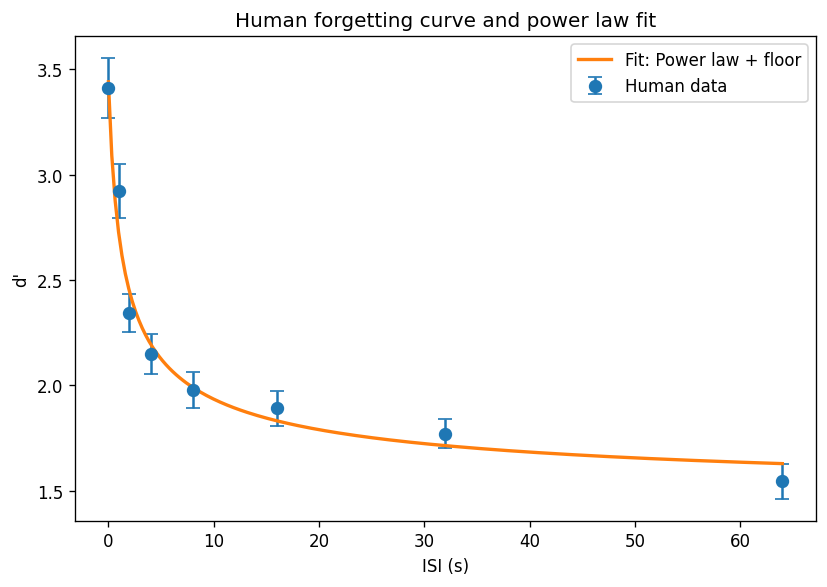

In [16]:
import matplotlib.pyplot as plt

print(isi_values)

def powerlaw_floor(t, a, alpha, t0, d_inf):
    return a * (t + t0) ** (-alpha) + d_inf

def powerlaw_floor_deriv(t, a, alpha, t0, d_inf):
    return -a * alpha * (t + t0) ** (-alpha - 1)


popt, pcov = curve_fit(
    powerlaw_floor, isi_values, human_dp,
    p0=[2.0, 0.3, 1.0, 0.5],
    sigma=human_sem, absolute_sigma=True,
    bounds=([0, 0.01, 0.1, 0], [20, 2.0, 20, 5.0]),
)
a, alpha, t0, d_inf = popt
perr = np.sqrt(np.diag(pcov))

dp_pred = powerlaw_floor(isi_values, *popt)
residuals = human_dp - dp_pred
ss_res = np.sum((residuals / human_sem) ** 2)
ss_tot = np.sum(((human_dp - np.mean(human_dp)) / human_sem) ** 2)
r_sq = 1 - ss_res / ss_tot

print(f"d'(t) = {a:.2f} * (t + {t0:.2f})^(-{alpha:.3f}) + {d_inf:.2f}")
print(f'a     = {a:.3f} +/- {perr[0]:.3f}')
print(f'alpha = {alpha:.3f} +/- {perr[1]:.3f}')
print(f't0    = {t0:.3f} +/- {perr[2]:.3f}')
print(f'd_inf = {d_inf:.3f} +/- {perr[3]:.3f}')
print(f'R^2   = {r_sq:.4f}')
print(f"Implied noise exponent: sigma^2(t) ~ t^({2*alpha - 1:.3f})")

# Plotting human data with fit
isi_plot = np.linspace(0, 64, 200)
fit_curve = powerlaw_floor(isi_plot, *popt)

print(fit_curve)

plt.figure(figsize=(7,5))
plt.errorbar(isi_values, human_dp, yerr=human_sem, fmt='o', label="Human data", capsize=4, color='C0', ms=7)
plt.plot(isi_plot, fit_curve, label="Fit: Power law + floor", color='C1', lw=2)
plt.xlabel("ISI (s)")
plt.ylabel("d'")
plt.title("Human forgetting curve and power law fit")
plt.legend()
plt.tight_layout()
plt.show()

## Cell 3: Build encoder and encode stimuli

In [5]:
encoder_cfg = dict(
    encoder_type='kell2018',
    model_name='kell2018',
    task='word_speaker_audioset',
    layer='relu0',
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=False,
    device='cuda',
)

encoder = build_encoder(encoder_cfg)
X0 = encode_stimuli(encoder, all_files)
print(f'X0 shape: {X0.shape}  (n_stimuli x feature_dim)')
print(f'X0 device: {X0.device}, dtype: {X0.dtype}')

LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/kell2018_word_speaker_audioset/


### WARNING: UNABLE TO FIND JSIN AUDIO TRAINING DATASET FILES. IF TRAINING AUDIO MODELS, CHANGE PATH SPECIFIED IN analysis_scripts/default_paths.py. MODELS CAN BE LOADED AND TESTED WITHOUT THESE FILES. ###
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/kell2018_word_audioset_speaker_decay_lr/5728d456-ddc2-4fc2-bf07-a41e658f36d4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/kell2018_word_audioset_speaker_decay_lr/5728d456-ddc2-4fc2-bf07-a41e658f36d4/5_checkpoint.pt' (epoch 6)
X0 shape: torch.Size([80, 886080])  (n_stimuli x feature_dim)
X0 device: cuda:0, dtype: torch.float32


## Cell 4: Compute $\Delta$ (mean nearest-neighbor distance)

Uses `distance_metric` from the config cell: same geometry for the analytical $\Delta$ in $\sigma^2(t)$ and for `run_model_core` scoring.

In [17]:
X0_np = X0.cpu().numpy()


def pairwise_dists_for_delta(X, metric_name):
    """Full pairwise distance matrix (diagonal inf) for mean NND / diagnostics."""
    if metric_name == 'cosine':
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
        d = 1.0 - Xn @ Xn.T
        np.fill_diagonal(d, np.inf)
        return d
    if metric_name == 'euclidean':
        d = squareform(pdist(X, metric='euclidean'))
        np.fill_diagonal(d, np.inf)
        return d
    if metric_name == 'manhattan':
        d = squareform(pdist(X, metric='cityblock'))
        np.fill_diagonal(d, np.inf)
        return d
    if metric_name in ('mahalanobis', 'loglikelihood'):
        # Theory ties Delta to Euclidean feature separation; use Euclidean NND when scoring differs.
        print(f'Note: using Euclidean NND for Delta while distance_metric={metric_name!r}')
        d = squareform(pdist(X, metric='euclidean'))
        np.fill_diagonal(d, np.inf)
        return d
    raise ValueError(
        f'Unsupported distance_metric={metric_name!r}. '
        "Use 'euclidean', 'cosine', 'manhattan', 'mahalanobis', or 'loglikelihood'."
    )


pair_dists = pairwise_dists_for_delta(X0_np, distance_metric)
nn_dists = pair_dists.min(axis=1)
Delta = float(np.mean(nn_dists))

print(f'Delta (mean NND, {distance_metric}) = {Delta:.6f}')
print(f'Median NND = {np.median(nn_dists):.6f}')
print(f'Min NND    = {np.min(nn_dists):.6f}')
print(f'Max NND    = {np.max(nn_dists):.6f}')

d_finite = pair_dists.copy()
d_finite[np.isinf(d_finite)] = np.nan
Delta_mean = float(np.nanmean(d_finite))
print(f'\nMean pairwise ({distance_metric}) dist = {Delta_mean:.6f}')
print(f'Ratio (mean / NND) = {Delta_mean / Delta:.2f}')

Delta (mean NND, euclidean) = 7205.962049
Median NND = 7205.181895
Min NND    = 5754.946652
Max NND    = 10190.123882

Mean pairwise (euclidean) dist = 9032.988611
Ratio (mean / NND) = 1.25


## Cell 5: Define AnalyticalNoiseSchedule

In [18]:
def sigma_sq_analytical(t, fit_params, Delta):
    dp = powerlaw_floor(t, *fit_params)
    dp_dot = powerlaw_floor_deriv(t, *fit_params)
    return -2 * Delta**2 * dp_dot / dp**3

class AnalyticalNoiseSchedule(NoiseSchedule):
    def __init__(self, fit_params, Delta, scale=1.0):
        self.fit_params = fit_params
        self.Delta = Delta
        self.scale = scale

    def __call__(self, age):
        if age <= 0:
            return 1e-10
        t = float(age)
        ssq = sigma_sq_analytical(t, self.fit_params, self.Delta)
        ssq = max(ssq, 1e-20)
        return max(self.scale * np.sqrt(ssq), 1e-10)

# Quick sanity check: print schedule values at a few ages
test_sched = AnalyticalNoiseSchedule(popt, Delta, scale=1.0)
for age in [0, 1, 4, 8, 16, 32, 64]:
    print(f'  age={age:3d} (ISI={age-1:2d}): sigma = {test_sched(age):.6f}')

  age=  0 (ISI=-1): sigma = 0.000000
  age=  1 (ISI= 0): sigma = 1408.020510
  age=  4 (ISI= 3): sigma = 900.158399
  age=  8 (ISI= 7): sigma = 657.448934
  age= 16 (ISI=15): sigma = 456.791796
  age= 32 (ISI=31): sigma = 304.927786
  age= 64 (ISI=63): sigma = 197.364791


## Cell 6: Calibrate sigma0

Find `sigma0_model` so that model d' at ISI=0 matches human d'(0).
We run a short simulation with near-zero diffusion noise and binary-search over sigma0.

In [20]:
from utls.runners_v2 import NoiseSchedule as _NS

class NearZeroSchedule(_NS):
    def __call__(self, age):
        return 1e-10

# Generate a small set of sequences for calibration
cal_isi_values = [0]
cal_sequences, _ = make_high_diversity_sequences(
    stimulus_pool=all_files,
    isi_values=cal_isi_values,
    n_sequences=8,
    length=60,
    min_pairs_per_isi=5,
    seed=99,
)

def eval_dprime_at_isi0(sigma0_test, n_mc=3):
    near_zero = NearZeroSchedule()
    runner_isi = 1  # ISI=0 in experiment -> age=1 in model
    all_hits, all_fas = [], []
    for rep in range(n_mc):
        run = run_model_core(
            sigma0=sigma0_test, X0=X0, name_to_idx=name_to_idx,
            experiment_list=cal_sequences, noise_schedule=near_zero,
            metric=distance_metric, seed=99 * 10_000 + rep,
        )
        all_hits.extend(run['isi_hit_dists'].get(runner_isi, []))
        all_fas.extend(run['fas'])
    if len(all_hits) < 3:
        return np.nan
    hits_scores = np.array([s for s, t in all_hits], dtype=float)
    fas_arr = np.array(all_fas, dtype=float)
    roc = roc_from_arrays(hits_scores, fas_arr, score_type=roc_score_type)
    if roc is None:
        return np.nan
    _, _, auc_val = roc
    return auroc_to_dprime(auc_val)

# Binary search for sigma0
target_dp0 = human_dp[0]
lo, hi = 0.0, Delta*2
print(f"Target d\'(ISI=0) = {target_dp0:.3f}")
print('Calibrating sigma0...')

for _ in range(15):
    mid = (lo + hi) / 2
    dp = eval_dprime_at_isi0(mid)
    print(f"  sigma0={mid:.4f} -> d\'={dp:.3f}")
    if np.isnan(dp) or dp > target_dp0:
        lo = mid  # need more noise to lower d'
    else:
        hi = mid

sigma0_model = (lo + hi) / 2
print(f"\nCalibrated sigma0_model = {sigma0_model:.4f}")

Aggregate ISI usage across all sequences:
  ISI -1: 160
  ISI 0: 320
Target d'(ISI=0) = 3.412
Calibrating sigma0...
  sigma0=7205.9620 -> d'=0.017
  sigma0=3602.9810 -> d'=0.017
  sigma0=1801.4905 -> d'=0.017
  sigma0=900.7453 -> d'=0.017
  sigma0=450.3726 -> d'=0.018
  sigma0=225.1863 -> d'=0.018
  sigma0=112.5932 -> d'=0.022
  sigma0=56.2966 -> d'=0.038
  sigma0=28.1483 -> d'=0.179
  sigma0=14.0741 -> d'=1.720
  sigma0=7.0371 -> d'=6.490
  sigma0=10.5556 -> d'=3.544
  sigma0=12.3149 -> d'=2.518
  sigma0=11.4352 -> d'=2.997
  sigma0=10.9954 -> d'=3.260

Calibrated sigma0_model = 10.7755


## Cell 7: Generate experiment sequences

In [21]:
experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=all_files,
    isi_values=list(isi_values),
    n_sequences=100,
    length=120,
    min_pairs_per_isi=4,
    seed=42,
)
print(f'{len(experiment_list)} sequences, length {len(experiment_list[0])}')

Aggregate ISI usage across all sequences:
  ISI -1: 4000
  ISI 0: 1102
  ISI 1: 930
  ISI 2: 1016
  ISI 4: 1004
  ISI 8: 998
  ISI 16: 976
  ISI 32: 992
  ISI 64: 982
100 sequences, length 120


## Cell 8: Run simulation

In [ ]:
scale = 1
n_mc = 3
runner_isi_values = [isi + 1 for isi in isi_values]

analytical_schedule = AnalyticalNoiseSchedule(
    fit_params=popt, Delta=Delta, scale=scale,
)

all_isi_hits = defaultdict(list)
all_fas = []

for rep in range(n_mc):
    print(f'  MC rep {rep+1}/{n_mc}...')
    run = run_model_core(
        sigma0=sigma0_model, X0=X0, name_to_idx=name_to_idx,
        experiment_list=experiment_list, noise_schedule=analytical_schedule,
        metric=distance_metric, seed=42 * 10_000 + rep,
    )
    for risi in runner_isi_values:
        all_isi_hits[risi].extend(run['isi_hit_dists'].get(risi, []))
    all_fas.extend(run['fas'])

# Compute d' per ISI
fas_arr = np.array(all_fas, dtype=float)
model_dp = {}
for exp_isi, risi in zip(isi_values, runner_isi_values):
    hits_raw = all_isi_hits.get(risi, [])
    if len(hits_raw) < 3:
        model_dp[exp_isi] = np.nan
        continue
    hits_scores = np.array([s for s, t in hits_raw], dtype=float)
    roc = roc_from_arrays(hits_scores, fas_arr, score_type=roc_score_type)
    if roc is not None:
        _, _, auc_val = roc
        model_dp[exp_isi] = auroc_to_dprime(auc_val)
    else:
        model_dp[exp_isi] = np.nan

model_dp_arr = np.array([model_dp.get(isi, np.nan) for isi in isi_values])
print(f"scale={scale}")
print("Model d':", np.round(model_dp_arr, 3))
print("Human d':", np.round(human_dp, 3))

  MC rep 1/3...


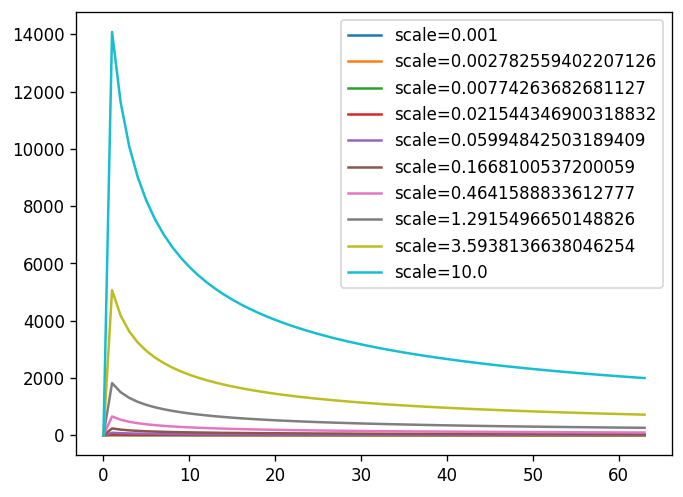

In [34]:

for scale in np.geomspace(0.001, 10, 10):
    sigma_scaled = []

    analytical_schedule = AnalyticalNoiseSchedule(
        fit_params=popt, Delta=Delta, scale=scale,
    )

    for i in range(64):
        #print(analytical_schedule(i))
        sigma_scaled.append(analytical_schedule(i))

    plt.plot(sigma_scaled, label=f'scale={scale}')
    
plt.legend()
plt.show()


## Cell 9: Compare model vs human

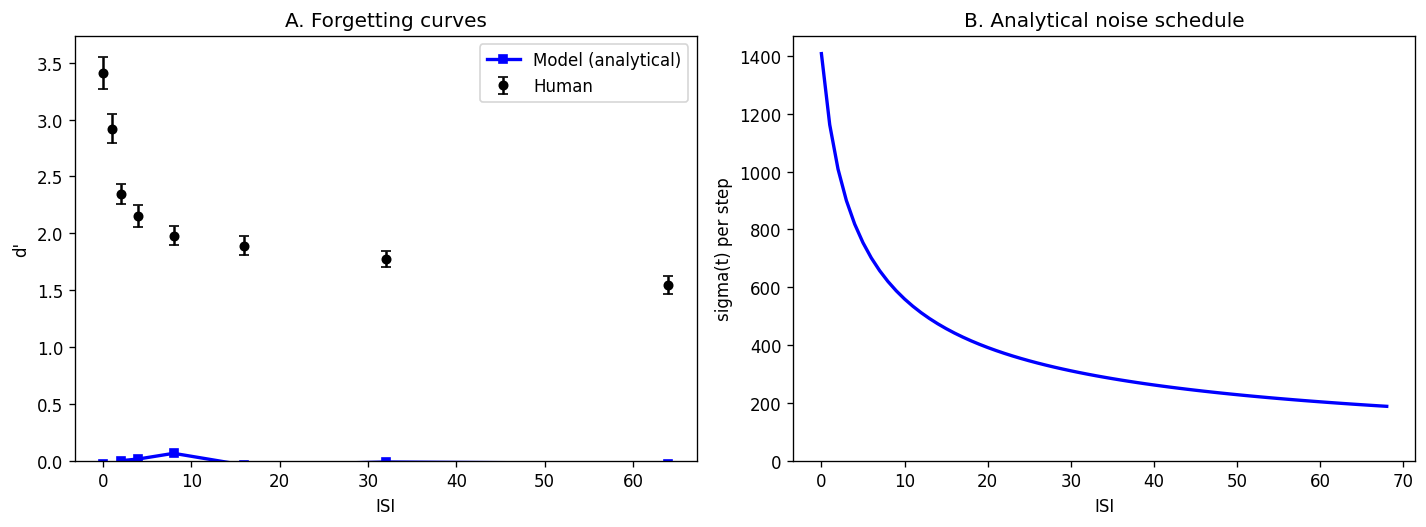


MSE = 5.4829


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: d' vs ISI overlay
ax = axes[0]
ax.errorbar(isi_values, human_dp, yerr=human_sem,
            fmt='ko', capsize=3, markersize=5, label='Human', zorder=3)
ax.plot(isi_values, model_dp_arr, 'bs-', markersize=5, lw=2,
        label='Model (analytical)')
ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('A. Forgetting curves')
ax.legend()
ax.set_ylim(bottom=0)

# Panel B: noise schedule
ax = axes[1]
ages = np.arange(1, 70)
schedule_vals = [analytical_schedule(a) for a in ages]
ax.plot(ages - 1, schedule_vals, 'b-', lw=2)
ax.set_xlabel('ISI')
ax.set_ylabel('sigma(t) per step')
ax.set_title('B. Analytical noise schedule')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('analytical_schedule_poc.png', dpi=200, bbox_inches='tight')
plt.show()

mse = np.nanmean((model_dp_arr - human_dp)**2)
print(f'\nMSE = {mse:.4f}')

## Cell 10: Scale factor sweep

If `scale=1.0` produces a curve that is way off, sweep over scale factors to find the best one.

In [41]:
scales = np.linspace(0.000001, 0.000050, 10)
sweep_results = {}

for sc in scales:
    schedule = AnalyticalNoiseSchedule(fit_params=popt, Delta=Delta, scale=sc)
    # 1 MC rep per scale for fast sweep
    run = run_model_core(
        sigma0=sigma0_model, X0=X0, name_to_idx=name_to_idx,
        experiment_list=experiment_list, noise_schedule=schedule,
        metric=distance_metric, seed=42,
    )

    dp_dict = {}
    fas_sc = np.array(run['fas'], dtype=float)
    for exp_isi, risi in zip(isi_values, runner_isi_values):
        hits_raw = run['isi_hit_dists'].get(risi, [])
        if len(hits_raw) < 3:
            dp_dict[exp_isi] = np.nan
            continue
        hits_sc = np.array([s for s, t in hits_raw], dtype=float)
        roc = roc_from_arrays(hits_sc, fas_sc, score_type=roc_score_type)
        if roc is not None:
            dp_dict[exp_isi] = auroc_to_dprime(roc[2])
        else:
            dp_dict[exp_isi] = np.nan

    dp_arr = np.array([dp_dict.get(isi, np.nan) for isi in isi_values])
    mse_sc = np.nanmean((dp_arr - human_dp)**2)
    sweep_results[sc] = {'dp': dp_arr, 'mse': mse_sc}
    print(f"  scale={sc:.4f}  MSE={mse_sc:.4f}  d\'={np.round(dp_arr, 2)}")

best_scale = min(sweep_results, key=lambda s: sweep_results[s]['mse'])
print(f"\nBest scale = {best_scale}  (MSE = {sweep_results[best_scale]['mse']:.4f})")

# Plot all scales
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(isi_values, human_dp, yerr=human_sem,
            fmt='ko', capsize=3, markersize=6, label='Human', zorder=5)
for sc in scales:
    r = sweep_results[sc]
    style = '-' if sc == best_scale else '--'
    alpha_plot = 1.0 if sc == best_scale else 0.4
    ax.plot(isi_values, r['dp'], style, alpha=alpha_plot,
            label=f"scale={sc} (MSE={r['mse']:.3f})")
ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('Scale factor sweep')
ax.legend(fontsize=7, ncol=2)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('analytical_schedule_scale_sweep.png', dpi=200, bbox_inches='tight')
plt.show()

  scale=0.0000  MSE=1.3572  d'=[3.23 3.37 3.17 3.21 3.24 3.3  3.3  3.25]
  scale=0.0000  MSE=1.3570  d'=[3.23 3.37 3.17 3.21 3.24 3.3  3.3  3.25]


KeyboardInterrupt: 

## Cell 11: Re-run with best scale (more MC reps)

In [ ]:
if best_scale != 1.0:
    print(f"Re-running with scale={best_scale}, n_mc=5...")
    best_schedule = AnalyticalNoiseSchedule(
        fit_params=popt, Delta=Delta, scale=best_scale,
    )
    all_isi_hits2 = defaultdict(list)
    all_fas2 = []
    for rep in range(5):
        print(f"  MC rep {rep+1}/5...")
        run = run_model_core(
            sigma0=sigma0_model, X0=X0, name_to_idx=name_to_idx,
            experiment_list=experiment_list, noise_schedule=best_schedule,
            metric=distance_metric, seed=42 * 10_000 + rep,
        )
        for risi in runner_isi_values:
            all_isi_hits2[risi].extend(run['isi_hit_dists'].get(risi, []))
        all_fas2.extend(run['fas'])

    fas_arr2 = np.array(all_fas2, dtype=float)
    best_dp = {}
    for exp_isi, risi in zip(isi_values, runner_isi_values):
        hits_raw = all_isi_hits2.get(risi, [])
        if len(hits_raw) < 3:
            best_dp[exp_isi] = np.nan
            continue
        hits_scores = np.array([s for s, t in hits_raw], dtype=float)
        roc = roc_from_arrays(hits_scores, fas_arr2, score_type=roc_score_type)
        if roc is not None:
            best_dp[exp_isi] = auroc_to_dprime(roc[2])
        else:
            best_dp[exp_isi] = np.nan

    best_dp_arr = np.array([best_dp.get(isi, np.nan) for isi in isi_values])
else:
    best_dp_arr = model_dp_arr
    best_schedule = analytical_schedule

best_mse = np.nanmean((best_dp_arr - human_dp)**2)

# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.errorbar(isi_values, human_dp, yerr=human_sem,
            fmt='ko', capsize=3, markersize=5, label='Human', zorder=3)
ax.plot(isi_values, best_dp_arr, 'bs-', markersize=5, lw=2,
        label=f"Model (scale={best_scale})")
ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('A. Best analytical schedule vs human')
ax.legend()
ax.set_ylim(bottom=0)

ax = axes[1]
ages = np.arange(1, 70)
vals = [best_schedule(a) for a in ages]
ax.plot(ages - 1, vals, 'b-', lw=2)
ax.set_xlabel('ISI')
ax.set_ylabel('sigma(t) per step')
ax.set_title('B. Analytical noise schedule (best scale)')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('analytical_schedule_best.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nFinal model d\': {np.round(best_dp_arr, 3)}")
print(f"Human d\':\t{np.round(human_dp, 3)}")
print(f"MSE = {best_mse:.4f}")
print(f"sigma0_model = {sigma0_model:.4f}")
print(f"best scale = {best_scale}")
print(f"Fit: a={a:.3f}, alpha={alpha:.3f}, t0={t0:.3f}, d_inf={d_inf:.3f}")